# Using the DuckDB Network Database

This notebook provides query helpers and visualisations for the enriched road network.

## Congestion columns in `driving.edges`

| Column | Written by | Description |
|---|---|---|
| `congestion_mapbox` | notebook 4 / pipeline | Latest Mapbox level (`low`/`moderate`/`heavy`/`severe`/`no data`) |
| `congestion_mapbox_at` | notebook 4 / pipeline | Timestamp of last Mapbox fetch |
| `congestion_google` | notebook 3b / pipeline | Latest Google Maps level |
| `congestion_google_at` | notebook 3b / pipeline | Timestamp of last Google fetch |

**Important:** Mapbox assigns `low` to all free-flowing roads. Google only colors congested roads — `no data` from Google usually means normal flow, not missing data.

## Other key tables

| Table | Schema | Content |
|---|---|---|
| `edges` | `driving` / `walking` / `cycling` | Road segments — geometry, speed, cost, H3 index, congestion |
| `runs` | `main` | One row per pipeline execution (source, timestamp) |
| `traffic_segments` | `main` | Raw Mapbox traffic segments per run |
| `edge_congestion_history` | `main` | Time-series: congestion per edge per run per **source** |
| `boundary_cells` | `main` | H3 hexagon grid |

In [1]:
%%time
import duckdb
import geopandas as gpd
import pandas as pd
import folium
import yaml
from pathlib import Path

# ── Configuration ─────────────────────────────────────────────────────────
NAME = 'sodermalm'
# ─────────────────────────────────────────────────────────────────────────

CONFIG_PATH = Path(f'../config/{NAME}.yaml')
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)
    DB_PATH = Path(cfg['output_path']) / f"{cfg['name']}.duckdb"
else:
    DB_PATH = Path(f'../db/{NAME}.duckdb')

print(f'Database: {DB_PATH}')
print(f'Exists  : {DB_PATH.exists()}  ({DB_PATH.stat().st_size/1_048_576:.1f} MB)' if DB_PATH.exists() else 'NOT FOUND')

Database: /home/kaveh/projects/osm-traffic-enrichment/db/sodermalm.duckdb
Exists  : True  (24.5 MB)
CPU times: user 1.96 s, sys: 173 ms, total: 2.13 s
Wall time: 427 ms


---
## Helper functions

These functions wrap common DuckDB queries into a clean Python API.
All functions accept an open DuckDB connection and return a pandas DataFrame or GeoDataFrame.

In [ ]:
%%time
from shapely import wkt
import pandas as pd

CONGESTION_COLORS = {
    'low':      '#00c800',
    'moderate': '#ffa500',
    'heavy':    '#ff4500',
    'severe':   '#8b0000',
    'no data':  '#cccccc',
}
CONGESTION_ORDER = ['low', 'moderate', 'heavy', 'severe', 'no data']


def connect(db_path=DB_PATH):
    con = duckdb.connect(str(db_path))
    con.execute('LOAD spatial')
    return con


def migrate_schema(con):
    """Migrate old single 'congestion' column → congestion_mapbox / congestion_google."""
    existing = {r[0] for r in con.execute(
        "SELECT column_name FROM information_schema.columns "
        "WHERE table_schema='driving' AND table_name='edges'"
    ).fetchall()}
    if 'congestion_mapbox' not in existing:
        print('Migrating schema ...')
        for col, dtype, default in [
            ('congestion_mapbox',    'VARCHAR',   "'no data'"),
            ('congestion_mapbox_at', 'TIMESTAMP', 'NULL'),
            ('congestion_google',    'VARCHAR',   "'no data'"),
            ('congestion_google_at', 'TIMESTAMP', 'NULL'),
        ]:
            con.execute(f"ALTER TABLE driving.edges ADD COLUMN IF NOT EXISTS "
                        f"{col} {dtype} DEFAULT {default}")
        if 'congestion' in existing:
            con.execute("UPDATE driving.edges SET congestion_mapbox = congestion "
                        "WHERE congestion IS NOT NULL")
        con.execute("ALTER TABLE edge_congestion_history ADD COLUMN IF NOT EXISTS source VARCHAR")
        con.execute("ALTER TABLE runs ADD COLUMN IF NOT EXISTS source VARCHAR")
        print('Migration done.')
    else:
        print('Schema is up to date.')


def list_tables(con):
    return con.execute("""
        SELECT table_schema AS schema, table_name,
               (SELECT count(*) FROM information_schema.columns c
                WHERE c.table_schema=t.table_schema AND c.table_name=t.table_name) AS columns
        FROM information_schema.tables t
        WHERE table_schema NOT IN ('pg_catalog','information_schema')
        ORDER BY schema, table_name
    """).df()


def to_gdf(df, wkt_col='wkt_geom', crs='EPSG:4326'):
    return gpd.GeoDataFrame(
        df.drop(columns=[wkt_col]),
        geometry=gpd.GeoSeries.from_wkt(df[wkt_col]),
        crs=crs,
    )


# ── Edge queries ──────────────────────────────────────────────────────────

def get_edges(con, mode='driving', highway=None, congestion=None,
              source='mapbox', name=None, limit=None):
    """
    source     : 'mapbox' | 'google'
    congestion : filter value applied to the chosen source column
    Note: timestamp columns are excluded — folium cannot JSON-serialize them.
    """
    col    = f'congestion_{source}'
    filters = []
    if highway:    filters.append(f"highway = '{highway}'")
    if congestion: filters.append(f"{col} = '{congestion}'")
    if name:       filters.append(f"lower(name) LIKE '%{name.lower()}%'")
    where = ('WHERE ' + ' AND '.join(filters)) if filters else ''
    lim   = f'LIMIT {limit}' if limit else ''

    df = con.execute(f"""
        SELECT edge_id, highway, name, oneway, length_m,
               maxspeed_kmh, cost_s, from_cell, to_cell,
               {col} AS congestion,
               congestion_mapbox, congestion_google,
               ST_AsText(geometry) AS wkt_geom
        FROM {mode}.edges
        {where}
        ORDER BY edge_id
        {lim}
    """).df()
    return to_gdf(df)


def get_network_stats(con, mode='driving'):
    return con.execute(f"""
        SELECT highway,
               count(*) AS edges,
               round(sum(length_m)/1000,1) AS km,
               round(avg(maxspeed_kmh),0) AS avg_speed_kmh,
               round(avg(cost_s),1) AS avg_cost_s
        FROM {mode}.edges GROUP BY highway ORDER BY edges DESC
    """).df()


# ── Congestion queries ────────────────────────────────────────────────────

def get_congestion_summary(con, source='mapbox', mode='driving'):
    col = f'congestion_{source}'
    return con.execute(f"""
        SELECT {col} AS congestion,
               count(*) AS edges,
               round(sum(length_m)/1000,1) AS km,
               round(count(*)*100.0 / sum(count(*)) OVER (),1) AS pct
        FROM {mode}.edges
        GROUP BY {col} ORDER BY km DESC
    """).df()


def get_congestion_history(con, edge_id=None, road_name=None,
                           source=None, limit=500):
    """source=None returns both; limit prevents freezing on large tables."""
    if edge_id:
        edge_filter = f'h.edge_id = {edge_id}'
    elif road_name:
        edge_filter = f"lower(e.name) LIKE '%{road_name.lower()}%'"
    else:
        raise ValueError('Supply either edge_id or road_name')
    src_filter = f"AND h.source = '{source}'" if source else ''
    return con.execute(f"""
        SELECT r.run_id, r.fetched_at,
               coalesce(h.source, r.source, '?') AS source,
               h.edge_id, e.name, e.highway,
               h.congestion, h.matched_at
        FROM edge_congestion_history h
        JOIN runs r          ON h.run_id  = r.run_id
        JOIN driving.edges e ON h.edge_id = e.edge_id
        WHERE {edge_filter} {src_filter}
        ORDER BY r.fetched_at, h.source, h.edge_id
        LIMIT {limit}
    """).df()


def get_runs(con):
    return con.execute("""
        SELECT r.run_id,
               coalesce(r.source, '?') AS source,
               r.boundary_name, r.zoom,
               r.fetched_at, r.n_tiles, r.n_segments,
               count(h.edge_id) AS edges_matched
        FROM runs r
        LEFT JOIN edge_congestion_history h ON h.run_id = r.run_id
        GROUP BY 1,2,3,4,5,6,7
        ORDER BY r.fetched_at
    """).df()


# ── H3 / spatial queries ──────────────────────────────────────────────────

def get_boundary_cells(con):
    tables = {r[0] for r in con.execute(
        "SELECT table_name FROM information_schema.tables WHERE table_schema='main'"
    ).fetchall()}
    if 'boundary_cells' not in tables:
        print('boundary_cells table not found — run notebook 5 (polygon_to_cells) first.')
        return gpd.GeoDataFrame()
    df = con.execute(
        "SELECT h3_id, resolution, ST_AsText(geometry) AS wkt_geom FROM boundary_cells"
    ).df()
    return to_gdf(df)


def get_edges_in_cell(con, h3_id, mode='driving', source='mapbox'):
    col = f'congestion_{source}'
    df = con.execute(f"""
        SELECT edge_id, highway, name, {col} AS congestion, length_m,
               ST_AsText(geometry) AS wkt_geom
        FROM {mode}.edges WHERE from_cell = '{h3_id}'
    """).df()
    return to_gdf(df)


def get_congestion_by_cell(con, mode='driving', source='mapbox'):
    col = f'congestion_{source}'
    return con.execute(f"""
        SELECT from_cell AS h3_id, count(*) AS edges,
               round(sum(length_m)/1000,2) AS km,
               mode() WITHIN GROUP (ORDER BY {col}) AS dominant_congestion
        FROM {mode}.edges WHERE from_cell IS NOT NULL
        GROUP BY from_cell ORDER BY edges DESC
    """).df()


# ── Visualisation ─────────────────────────────────────────────────────────

def plot_edges(gdf, color_col='congestion', zoom=14, tiles='OpenStreetMap'):
    """Plot edges. Timestamp columns are excluded — folium cannot serialize them."""
    lines = gdf[gdf.geometry.geom_type.isin(['LineString','MultiLineString'])].copy()
    if lines.empty:
        print('No line geometries.')
        return
    # Drop any datetime/Timestamp columns before GeoJSON serialization
    ts_cols = [c for c in lines.columns
               if pd.api.types.is_datetime64_any_dtype(lines[c])]
    lines = lines.drop(columns=ts_cols, errors='ignore')
    bds    = lines.total_bounds
    center = [(bds[1]+bds[3])/2, (bds[0]+bds[2])/2]
    m      = folium.Map(location=center, zoom_start=zoom, tiles=tiles)
    folium.GeoJson(
        lines.__geo_interface__,
        style_function=lambda feat: {
            'color':  CONGESTION_COLORS.get(
                feat['properties'].get(color_col, 'no data'), '#cccccc'),
            'weight': 3 if feat['properties'].get(color_col,'no data') != 'no data' else 1.5,
        },
        tooltip=None, popup=None,
    ).add_to(m)
    return m


print('Helpers ready:')
print('  get_edges(source=mapbox|google)  get_congestion_summary(source=)')
print('  get_congestion_history(limit=500) get_runs()  plot_edges(color_col=)')

---
## 1. Connect and inspect the database

In [3]:
%%time
con = connect()
migrate_schema(con)   # no-op if schema is already up to date
print('All tables in the database:')
display(list_tables(con))

Schema is up to date.
All tables in the database:


,schema,table_name,columns
0,cycling,edge_graph,4
1,cycling,edges,19
2,cycling,nodes,3
3,cycling,way_nodes,3
4,cycling,ways,10
5,driving,edge_graph,4
6,driving,edges,23
7,driving,nodes,3
8,driving,turn_restrictions,5
9,driving,way_nodes,3


CPU times: user 354 ms, sys: 8.51 ms, total: 362 ms
Wall time: 63.8 ms


---
## 2. Network statistics

In [4]:
%%time
print('Network statistics (driving mode):')
display(get_network_stats(con))

Network statistics (driving mode):


,highway,edges,km,avg_speed_kmh,avg_cost_s
0,residential,2819,94.2,30.0,4.0
1,service,909,43.4,20.0,8.6
2,tertiary,365,17.5,35.0,4.9
3,unclassified,195,12.7,34.0,7.2
4,secondary,173,15.4,44.0,7.5
5,primary,21,1.6,50.0,5.4
6,living_street,17,0.8,18.0,11.2
7,trunk,15,4.6,60.0,18.4
8,secondary_link,14,0.2,51.0,0.8
9,trunk_link,14,1.1,47.0,6.3


CPU times: user 10.9 ms, sys: 5.07 ms, total: 16 ms
Wall time: 6.81 ms


---
## 3. Congestion overview

In [5]:
%%time
print('Mapbox congestion distribution:')
display(get_congestion_summary(con, source='mapbox'))
print('Google congestion distribution:')
display(get_congestion_summary(con, source='google'))

Mapbox congestion distribution:


,congestion,edges,km,pct
0,low,4240,174.2,93.1
1,no data,89,6.9,2.0
2,heavy,143,5.3,3.1
3,moderate,82,5.2,1.8


Google congestion distribution:


,congestion,edges,km,pct
0,no data,4363,178.8,95.8
1,moderate,111,8.1,2.4
2,heavy,78,4.6,1.7
3,low,2,0.1,0.0


CPU times: user 14 ms, sys: 0 ns, total: 14 ms
Wall time: 10.8 ms


In [6]:
%%time
# Visualise all edges coloured by Mapbox congestion
edges = get_edges(con, source='mapbox')
print(f'{len(edges):,} edges  |  source=mapbox')
plot_edges(edges, color_col='congestion')

4,554 edges  |  source=mapbox
CPU times: user 101 ms, sys: 0 ns, total: 101 ms
Wall time: 95.6 ms


TypeError: Object of type Timestamp is not JSON serializable

---
## 4. Filter edges

### By congestion level

In [7]:
%%time
# Heavy congestion edges — Mapbox source
heavy = get_edges(con, congestion='heavy', source='mapbox')
print(f'Heavy (Mapbox): {len(heavy)} edges  ({heavy["length_m"].sum()/1000:.1f} km)')
display(heavy[['edge_id','highway','name','length_m','congestion']].head(10))

# Google heavy
heavy_g = get_edges(con, congestion='heavy', source='google')
print(f'Heavy (Google): {len(heavy_g)} edges  ({heavy_g["length_m"].sum()/1000:.1f} km)')

Heavy (Mapbox): 143 edges  (5.3 km)


,edge_id,highway,name,length_m,congestion
0,29,secondary,Långholmsgatan,15.844874,heavy
1,69,residential,Havregatan,12.608045,heavy
2,141,tertiary,Götgatan,20.051088,heavy
3,270,secondary,Ringvägen,7.028281,heavy
4,285,residential,Tegelviksgatan,15.106542,heavy
5,295,secondary,Götgatan,117.130028,heavy
6,296,tertiary,Götgatan,29.669481,heavy
7,298,secondary,Ringvägen,7.389982,heavy
8,299,residential,Åsögatan,6.820893,heavy
9,310,secondary,Ringvägen,39.459187,heavy


Heavy (Google): 78 edges  (4.6 km)
CPU times: user 12.5 ms, sys: 0 ns, total: 12.5 ms
Wall time: 11.2 ms


### By road type

In [8]:
%%time
motorways = get_edges(con, highway='motorway')
print(f'Motorway edges: {len(motorways)}')
plot_edges(motorways)

Motorway edges: 0
No line geometries.
CPU times: user 3.65 ms, sys: 0 ns, total: 3.65 ms
Wall time: 2.92 ms


### By road name

In [9]:
%%time
ring = get_edges(con, name='Ringvägen', source='mapbox')
print(f'Ringvägen: {len(ring)} edges')
print(f'  Mapbox: {ring["congestion_mapbox"].value_counts().to_dict()}')
print(f'  Google: {ring["congestion_google"].value_counts().to_dict()}')
plot_edges(ring, color_col='congestion_mapbox')

Ringvägen: 171 edges
  Mapbox: {'low': 140, 'heavy': 24, 'no data': 6, 'moderate': 1}
  Google: {'no data': 150, 'heavy': 13, 'moderate': 8}
CPU times: user 12.5 ms, sys: 0 ns, total: 12.5 ms
Wall time: 11.8 ms


TypeError: Object of type Timestamp is not JSON serializable

---
## 5. Congestion history (time series)

`edge_congestion_history` records congestion per edge per run per **source**.
Use `source='mapbox'` or `source='google'` to filter, or `source=None` for both.
A `limit` is applied by default (500 rows) to avoid freezing on large tables.

In [10]:
%%time
print('Pipeline runs (source, timestamp, edges matched):')
display(get_runs(con))

Pipeline runs (source, timestamp, edges matched):


,run_id,source,boundary_name,zoom,fetched_at,n_tiles,n_segments,edges_matched
0,1,mapbox,sodermalm,0,2026-05-21 20:52:02,0,3554,4465
1,2,google,sodermalm,14,2026-05-21 20:52:22,0,8,191


CPU times: user 8.99 ms, sys: 341 μs, total: 9.33 ms
Wall time: 6.15 ms


In [11]:
%%time
# History for a specific road — both sources, limited to 500 rows
history = get_congestion_history(con, road_name='Ringvägen', source=None, limit=500)
if history.empty:
    print('No history yet — run the pipeline at least once.')
else:
    print(f'{len(history)} history rows for Ringvägen:')
    display(history[['run_id','fetched_at','source','edge_id','name','congestion']])

186 history rows for Ringvägen:


,run_id,fetched_at,source,edge_id,name,congestion
0,1,2026-05-21 20:52:02,mapbox,6,Ringvägen,low
1,1,2026-05-21 20:52:02,mapbox,16,Ringvägen,low
2,1,2026-05-21 20:52:02,mapbox,58,Ringvägen,low
3,1,2026-05-21 20:52:02,mapbox,81,Ringvägen,low
4,1,2026-05-21 20:52:02,mapbox,82,Ringvägen,low
...,...,...,...,...,...,...
181,2,2026-05-21 20:52:22,google,2573,Ringvägen,heavy
182,2,2026-05-21 20:52:22,google,2695,Ringvägen,heavy
183,2,2026-05-21 20:52:22,google,2800,Ringvägen,heavy
184,2,2026-05-21 20:52:22,google,2865,Ringvägen,moderate


CPU times: user 9.49 ms, sys: 0 ns, total: 9.49 ms
Wall time: 6.82 ms


---
## 6. H3 spatial queries

Each edge has `from_cell` and `to_cell` H3 indices that link it to the boundary hex grid.

In [12]:
%%time
cells = get_boundary_cells(con)
print(f'{len(cells)} H3 cells at resolution {cells["resolution"].iloc[0]}')

cell_cong = get_congestion_by_cell(con, source='mapbox')
print(f'\nDominant congestion per H3 cell (Mapbox, top 10):')
display(cell_cong.head(10))

CatalogException: Catalog Error: Table with name boundary_cells does not exist!
Did you mean "boundary"?

LINE 1: ... h3_id, resolution, ST_AsText(geometry) AS wkt_geom FROM boundary_cells
                                                                    ^

In [13]:
%%time
# Query all edges in a specific H3 cell
sample_cell = cell_cong.iloc[0]['h3_id']   # most-connected cell
cell_edges  = get_edges_in_cell(con, sample_cell)
print(f'Cell {sample_cell}: {len(cell_edges)} edges')
plot_edges(cell_edges)

NameError: name 'cell_cong' is not defined

---
## 7. Raw SQL queries

For anything the helper functions don't cover, run SQL directly.
DuckDB supports full SQL including spatial functions.

In [14]:
%%time
# Example: total network length and cost per mode
con.execute("""
    SELECT 'driving' AS mode,
           count(*)                     AS edges,
           round(sum(length_m)/1000, 1) AS km,
           round(sum(cost_s)/3600, 1)   AS total_travel_hours
    FROM driving.edges
    UNION ALL
    SELECT 'walking', count(*), round(sum(length_m)/1000,1), round(sum(cost_s)/3600,1)
    FROM walking.edges
    UNION ALL
    SELECT 'cycling', count(*), round(sum(length_m)/1000,1), round(sum(cost_s)/3600,1)
    FROM cycling.edges
""").df()

CPU times: user 3.06 ms, sys: 101 μs, total: 3.16 ms
Wall time: 1.71 ms


,mode,edges,km,total_travel_hours
0,driving,4554,191.6,6.8
1,walking,15414,436.0,87.2
2,cycling,5916,252.5,16.8


In [ ]:
%%time
# Find edges within 500 m of a given point (lon, lat)
LON, LAT = 18.07, 59.315   # somewhere in Södermalm

nearby = con.execute(f"""
    SELECT edge_id, name, highway,
           congestion_mapbox, congestion_google,
           round(length_m) AS length_m,
           round(ST_Distance(
               ST_Transform(geometry,    'EPSG:4326', 'EPSG:3857'),
               ST_Transform(ST_Point({LON}, {LAT}), 'EPSG:4326', 'EPSG:3857')
           )) AS dist_m
    FROM driving.edges
    ORDER BY dist_m
    LIMIT 10
""").df()

print(f'10 nearest edges to ({LAT}, {LON}):')
display(nearby)

---
## Mapbox vs Google — comparison

This section compares the congestion reported by each source for the same road network.

**Key difference to keep in mind:**
- **Mapbox** always assigns `low` to free-flowing roads → high coverage, many `low` edges
- **Google** only colors *congested* roads → free-flowing roads stay `no data`

So a road with Mapbox=`low` and Google=`no data` is most likely **flowing normally** —
both sources agree, they just express it differently.

### Comparison categories

| Mapbox | Google | Interpretation |
|---|---|---|
| `low` | `no data` | Normal flow — both agree, Google just doesn't color it |
| `low` | `low` | Both confirm low congestion |
| `moderate`/`heavy`/`severe` | `no data` | Mapbox detects congestion, Google doesn't (or missed it) |
| same non-low level | same non-low level | Both sources confirm congestion |
| different non-low levels | different non-low levels | Sources disagree — worth investigating |

In [16]:
%%time
# Migration already done in the connect/inspect cell above.
# Load both congestion columns for comparison.
df = con.execute("""
    SELECT edge_id, highway, name, length_m,
           congestion_mapbox, congestion_mapbox_at,
           congestion_google,  congestion_google_at,
           ST_AsText(geometry) AS wkt_geom
    FROM driving.edges
""").df()

both = gpd.GeoDataFrame(
    df,
    geometry=gpd.GeoSeries.from_wkt(df['wkt_geom']),
    crs='EPSG:4326',
).reset_index(drop=True)

mapbox_ok = (both['congestion_mapbox'] != 'no data').sum()
google_ok  = (both['congestion_google'] != 'no data').sum()
total      = len(both)

print(f'Total edges       : {total:,}')
print(f'Mapbox coverage   : {mapbox_ok:,}  ({mapbox_ok/total*100:.1f}%)')
print(f'Google coverage   : {google_ok:,}  ({google_ok/total*100:.1f}%)')

print('\nMapbox distribution:')
display(both['congestion_mapbox'].value_counts().reindex(CONGESTION_ORDER).dropna()
        .reset_index().rename(columns={'congestion_mapbox':'congestion','count':'edges'}))
print('Google distribution:')
display(both['congestion_google'].value_counts().reindex(CONGESTION_ORDER).dropna()
        .reset_index().rename(columns={'congestion_google':'congestion','count':'edges'}))

Total edges       : 4,554
Mapbox coverage   : 4,465  (98.0%)
Google coverage   : 191  (4.2%)

Mapbox distribution:


,congestion,edges
0,low,4240.0
1,moderate,82.0
2,heavy,143.0
3,no data,89.0


Google distribution:


,congestion,edges
0,low,2.0
1,moderate,111.0
2,heavy,78.0
3,no data,4363.0


CPU times: user 21.7 ms, sys: 0 ns, total: 21.7 ms
Wall time: 18.5 ms


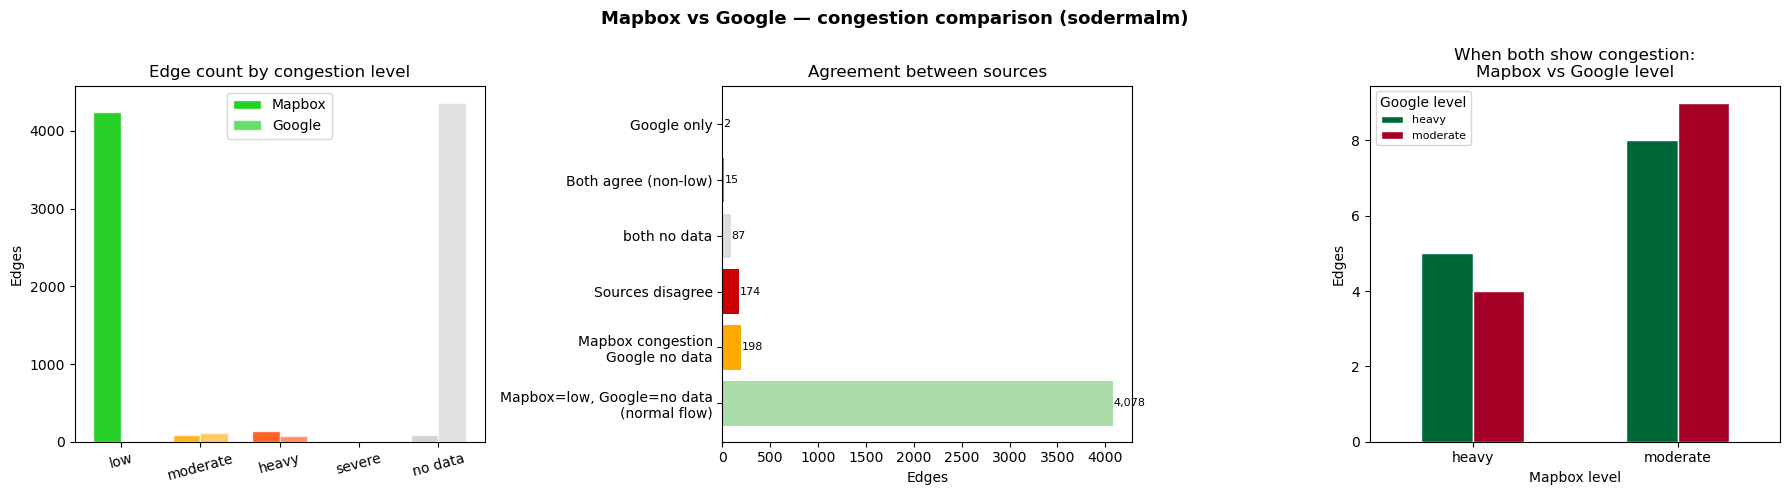

CPU times: user 386 ms, sys: 29.6 ms, total: 416 ms
Wall time: 487 ms


In [17]:
%%time
# ── Side-by-side bar chart ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

COLORS  = {'low':'#00c800','moderate':'#ffa500','heavy':'#ff4500','severe':'#8b0000','no data':'#cccccc'}
ORDER   = ['low','moderate','heavy','severe','no data']
sources = {'Mapbox':'congestion_mapbox', 'Google':'congestion_google'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Mapbox vs Google — congestion comparison ({NAME})', fontsize=13, fontweight='bold')

# ── Plot 1: edge count per level per source ───────────────────────────────
ax = axes[0]
x   = np.arange(len(ORDER))
w   = 0.35
for i, (label, col) in enumerate(sources.items()):
    counts = [both[col].value_counts().get(lvl, 0) for lvl in ORDER]
    bars = ax.bar(x + i*w, counts, w, label=label,
                  color=[COLORS[l] for l in ORDER],
                  edgecolor='white', alpha=0.85 if i == 0 else 0.6)
ax.set_xticks(x + w/2); ax.set_xticklabels(ORDER, rotation=15)
ax.set_title('Edge count by congestion level')
ax.set_ylabel('Edges')
ax.legend(['Mapbox','Google'])

# ── Plot 2: agreement / disagreement categories ───────────────────────────
ax = axes[1]
lines = both[both.geometry.geom_type.isin(['LineString','MultiLineString'])].copy()
lines['category'] = 'both no data'
lines.loc[(lines['congestion_mapbox']=='low') &
          (lines['congestion_google']=='no data'),  'category'] = 'Mapbox=low, Google=no data\n(normal flow)'
lines.loc[(lines['congestion_mapbox']!='no data') &
          (lines['congestion_google']!='no data') &
          (lines['congestion_mapbox']==lines['congestion_google']), 'category'] = 'Both agree (non-low)'
lines.loc[(lines['congestion_mapbox'].isin(['moderate','heavy','severe'])) &
          (lines['congestion_google']=='no data'),  'category'] = 'Mapbox congestion\nGoogle no data'
lines.loc[(lines['congestion_mapbox']!='no data') &
          (lines['congestion_google']!='no data') &
          (lines['congestion_mapbox']!=lines['congestion_google']), 'category'] = 'Sources disagree'
lines.loc[(lines['congestion_mapbox']=='no data') &
          (lines['congestion_google']!='no data'),  'category'] = 'Google only'

cat_counts = lines['category'].value_counts()
cat_colors = {
    'Mapbox=low, Google=no data\n(normal flow)': '#aaddaa',
    'Both agree (non-low)':                       '#ff6600',
    'Mapbox congestion\nGoogle no data':           '#ffaa00',
    'Sources disagree':                            '#cc0000',
    'Google only':                                 '#0088cc',
    'both no data':                                '#dddddd',
}
ax.barh(cat_counts.index, cat_counts.values,
        color=[cat_colors.get(c,'#999999') for c in cat_counts.index])
ax.set_title('Agreement between sources')
ax.set_xlabel('Edges')
for i, v in enumerate(cat_counts.values):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=8)

# ── Plot 3: roads where both sources show congestion ─────────────────────
ax = axes[2]
both_congested = both[(both['congestion_mapbox'].isin(['moderate','heavy','severe'])) &
                      (both['congestion_google'].isin(['moderate','heavy','severe']))]
if len(both_congested):
    cross = both_congested.groupby(['congestion_mapbox','congestion_google']).size().unstack(fill_value=0)
    cross.plot(kind='bar', ax=ax, colormap='RdYlGn_r', edgecolor='white')
    ax.set_title('When both show congestion:\nMapbox vs Google level')
    ax.set_xlabel('Mapbox level'); ax.set_ylabel('Edges')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Google level', fontsize=8)
else:
    ax.text(0.5, 0.5, 'No edges where\nboth sources show congestion',
            ha='center', va='center', transform=ax.transAxes, fontsize=11, color='gray')
    ax.set_title('When both show congestion')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
### Side-by-side map: Mapbox (left) vs Google (right)

The two maps use identical color scales so you can compare coverage and levels visually.

In [18]:
%%time
from IPython.display import display, HTML

lines = both[both.geometry.geom_type.isin(['LineString','MultiLineString'])]
bds   = lines.total_bounds
center = [(bds[1]+bds[3])/2, (bds[0]+bds[2])/2]

def make_map(gdf, col, title):
    m = folium.Map(location=center, zoom_start=13, tiles='OpenStreetMap')
    folium.GeoJson(
        gdf.__geo_interface__,
        style_function=lambda feat, c=col: {
            'color':  CONGESTION_COLORS.get(feat['properties'].get(c,'no data'), '#cccccc'),
            'weight': 3 if feat['properties'].get(c,'no data') != 'no data' else 1,
        },
        tooltip=folium.GeoJsonTooltip(fields=[col,'highway','name'],
                                       aliases=['Congestion','Type','Name'],
                                       localize=True),
        popup=None,
    ).add_to(m)
    folium.map.Marker(
        [bds[3], (bds[0]+bds[2])/2],
        icon=folium.DivIcon(html=f'<div style="font-size:14px;font-weight:bold;'
                                 f'background:white;padding:4px 8px;border-radius:4px;'
                                 f'border:1px solid #ccc">{title}</div>')
    ).add_to(m)
    return m

m_mapbox = make_map(lines, 'congestion_mapbox', 'Mapbox')
m_google = make_map(lines, 'congestion_google',  'Google Maps')

# Render both maps side by side using an HTML iframe trick
m_mapbox.save('/tmp/_mapbox_map.html')
m_google.save('/tmp/_google_map.html')

html = """
<div style="display:flex;gap:8px">
  <div style="flex:1">
    <h4 style="text-align:center;margin:4px 0">🟦 Mapbox</h4>
    <iframe src="/tmp/_mapbox_map.html" width="100%" height="480" frameborder="0"></iframe>
  </div>
  <div style="flex:1">
    <h4 style="text-align:center;margin:4px 0">🟥 Google Maps</h4>
    <iframe src="/tmp/_google_map.html" width="100%" height="480" frameborder="0"></iframe>
  </div>
</div>"""
display(HTML(html))

TypeError: Object of type Timestamp is not JSON serializable

In [19]:
con.close()
print('Connection closed.')

Connection closed.
